# TrustLens: Model Analysis Demo
This notebook demonstrates how to evaluate the trustworthiness of an ML model using TrustLens.
TrustLens goes beyond standard accuracy metrics to uncover calibration, bias, and confidence issues.

## 1. Installation
First, install the library.

In [ ]:
!pip install trustlens tqdm matplotlib scikit-learn

## 2. Quick Analysis (Zero-Friction Entry)
Try TrustLens instantly with `quick_analyze`. It auto-loads a sample dataset if you don't provide one, making it easy to see the output immediately.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



TrustLens Analysis: breast_cancer (demo)
Status: Loaded demo model and breast_cancer validation data.

TrustLens Analysis Report
Timestamp : 2026-09-29T09:37:44.013504+00:00
Model     : LogisticRegression
Samples   : 171
Classes   : 2

TRUST SCORE: 93/100 [A]
Assessment : High Trust - no critical issues detected

Deployment Verdict: PASS

Reasons:
✓ Calibration assessment completed
✓ Failure assessment completed

Primary Risk:
Calibration

Recommendations:
• Model meets all trustworthiness criteria for deployment.

Key Observations:
- Warning: Calibration is acceptable (score 75-89), but could be improved.
- ℹ Info: No bias detected (margin: 0.10 from 0.10 limit).

Dimension Breakdown:
- Calibration Score :  87.2/100
- Failure Score     :  99.6/100

Calibration Analysis
- Brier Score: 0.0208
- Ece: 0.0319
- Mce: 0.7484
- Overconfidence Error: 0.0102
- N Samples: 171

Failure Analysis
- Confidence Auroc: 0.9879
- N Classes: 2
- Accuracy: 0.9649
- Baseline Accuracy: 0.6316
- N Samples: 

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


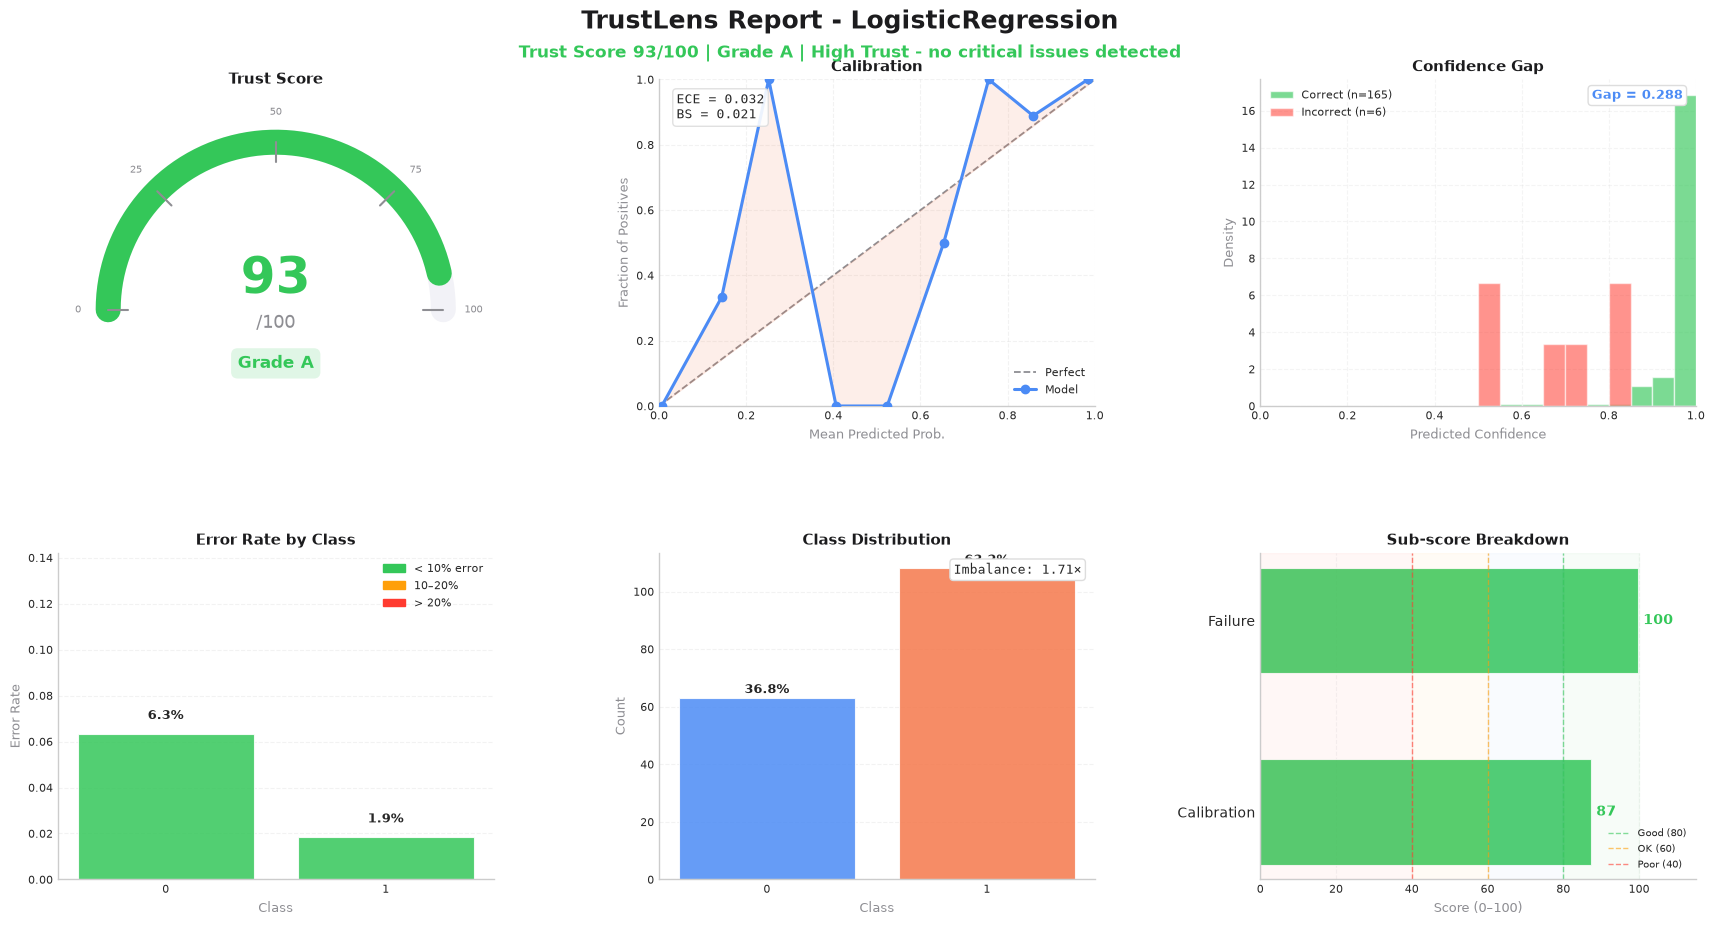

In [2]:
%matplotlib notebook
%matplotlib ipympl
from trustlens import quick_analyze

# Run a complete analysis on the breast cancer dataset instantly
report_quick = quick_analyze(dataset="breast_cancer")

Even in quick analysis mode, you can immediately visualize bias diagnostics if sensitive features were inferred or provided.

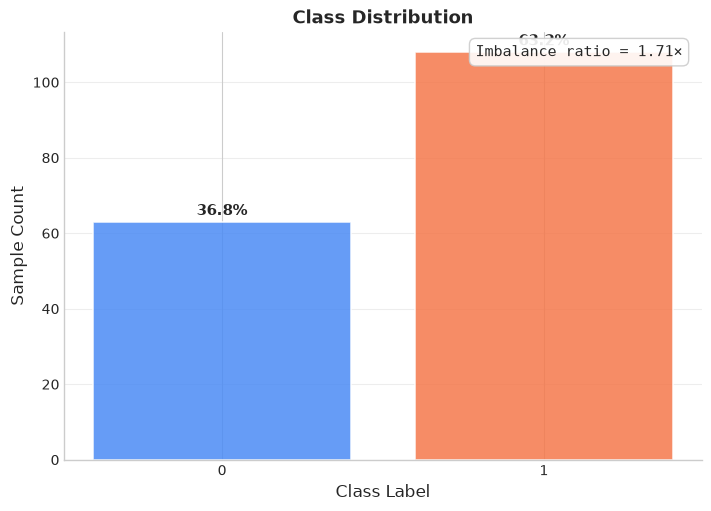

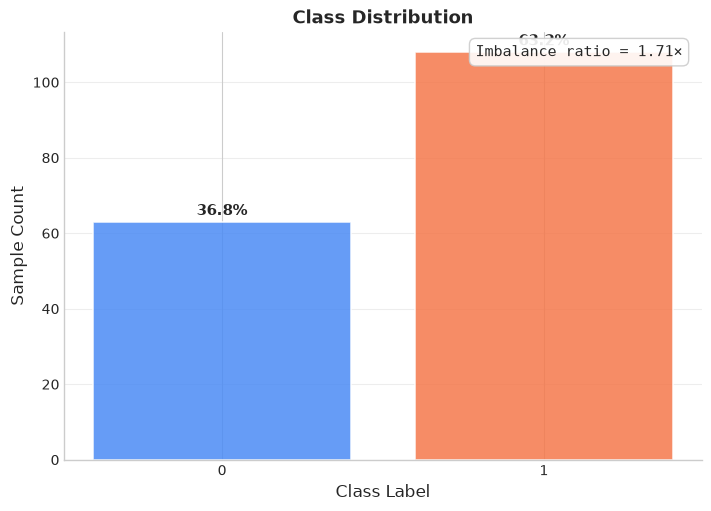

In [3]:
# Visualize bias for the quick analysis report
report_quick.plot_bias()

## 3. Rich UI Integration
TrustLens supports **Rich Jupyter Display**. Simply typing `report` in a cell will render a styled dashboard with the Trust Score, grade, and key observations.

TrustReport(model='LogisticRegression', score=93/100 [A], samples=171, modules=[calibration, failure, bias])
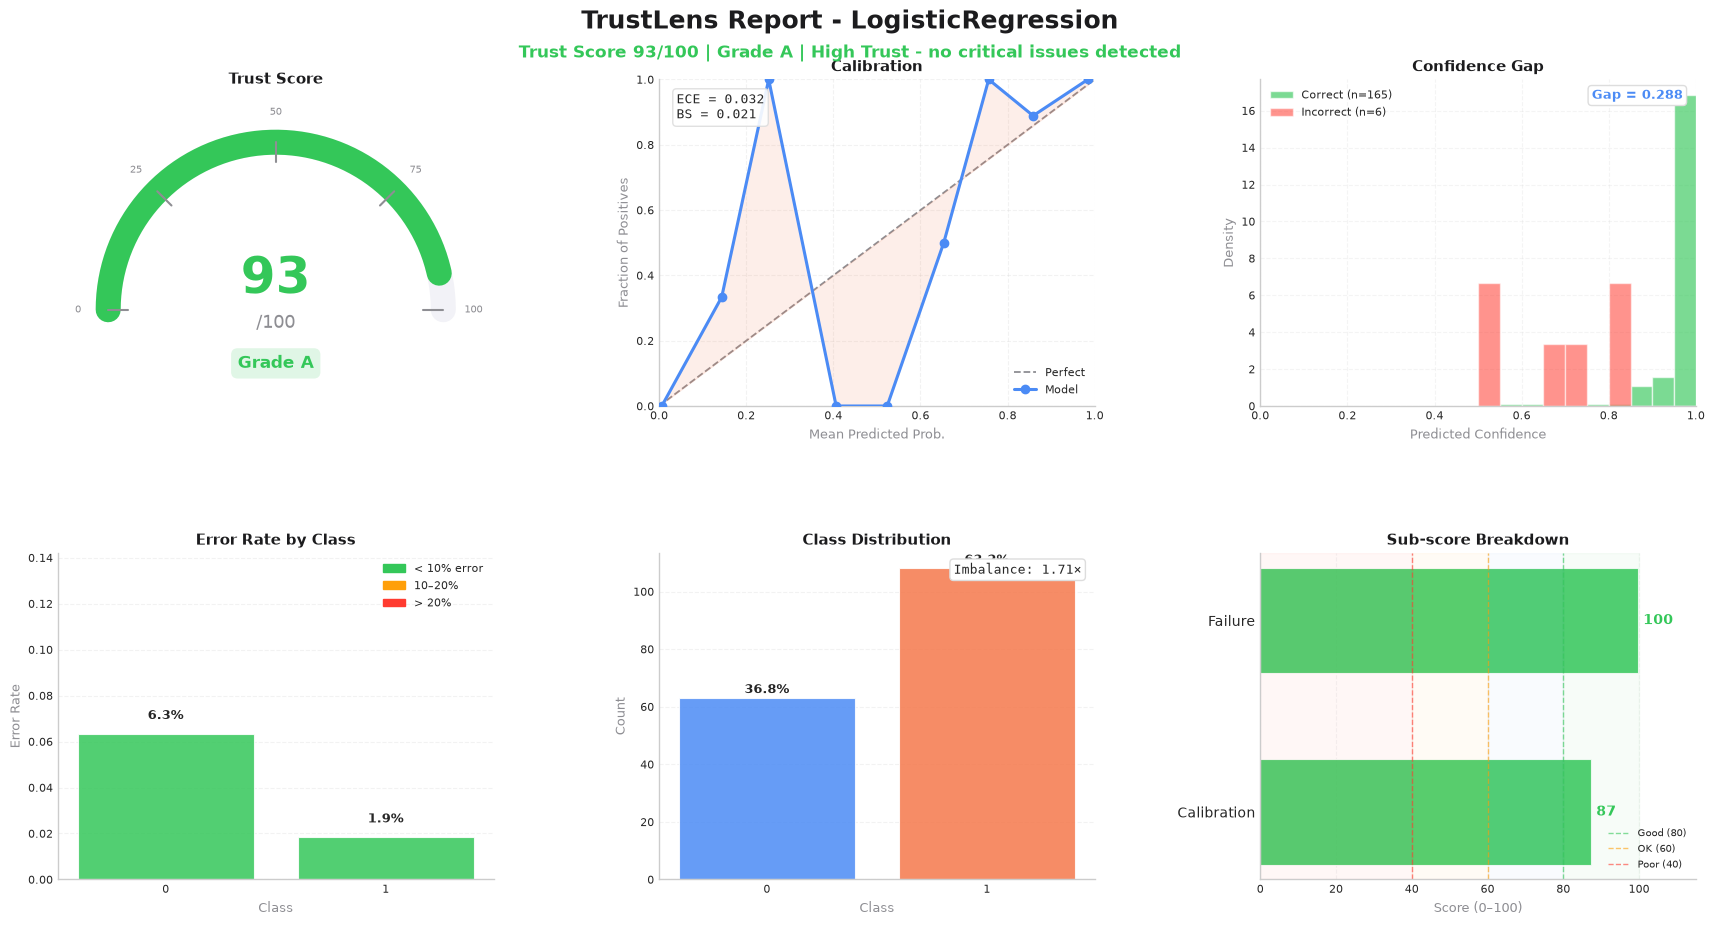

In [4]:
# This will render the styled HTML dashboard automatically
report_quick

## 4. Custom Model Analysis
For your own models, step through data preparation and analysis manually.

In [5]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from trustlens import analyze

# Generate synthetic dataset with class imbalance (80/20)
X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.8, 0.2], random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Add a sensitive feature for bias detection
rng = np.random.default_rng(42)  # seeded so the stored outputs are reproducible
age_group = rng.choice(['18-30', '31-50', '51+'], size=len(y_val))

# Train Model
model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Run Analysis with sensitive features
report = analyze(
  model, 
  X_val, 
  y_val, 
  sensitive_features={"age_group": age_group}
)

Running calibration analysis...
Running failure analysis...
Running bias analysis...


## 5. Failure Analysis
Identify high-confidence mistakes where the model is 'certain' but wrong.

In [6]:
report.show_failures(top_k=5)


CRITICAL FAILURES
RandomForestClassifier | 40 total errors / 600 samples (6.7%)

#    Sample     True   Pred   Confidence   Danger
1    144           1      0       99.3% CRITICAL
2    232           1      0       93.6%     HIGH
3    433           1      0       90.5%     HIGH
4    489           1      0       87.0%     HIGH
5    100           1      0       85.9%     HIGH

 Insights:
   Mean confidence on top failures: 91.3%
   These are high-confidence mistakes - the model is
   certain it is right, but it is wrong.
   Overconfidence detected - consider calibration.



In [7]:
report.show()


TrustLens Analysis Report
Timestamp : 2026-09-29T09:37:45.767737+00:00
Model     : RandomForestClassifier
Samples   : 600
Classes   : 2

TRUST SCORE: 46/100 [C]
Assessment : Moderate Trust - Fairness gap 0.144 limits the score to 46

Score Summary:
  Weighted Score    : 77
  Cap               : Fairness gap 0.144 limits the score to 46
  Final Score       : 46

Score Explanation:
  - Dominant Issue  : Bias (52.1/100)

Deployment Verdict: CAUTION

Reasons:
✓ Calibration assessment completed
✓ Failure assessment completed
✗ Fairness below 60 (52.1/100)
✗ Fairness gap 0.144 limits the score to 46

Primary Risk:
Fairness

Recommendations:
• Investigate subgroup performance disparities and consider fairness constraints before deployment.

Key Observations:
- Warning: Calibration is acceptable (score 75-89), but could be improved.
- ℹ Info: No bias detected (margin: 0.06 from 0.10 limit).

Dimension Breakdown:
- Calibration Score :  81.6/100
- Failure Score     :  93.6/100
- Bias Score     

## 6. Fairness Visualization
TrustLens also provides visual diagnostics for fairness. The plot below highlights subgroup performance and fairness gaps across sensitive features.

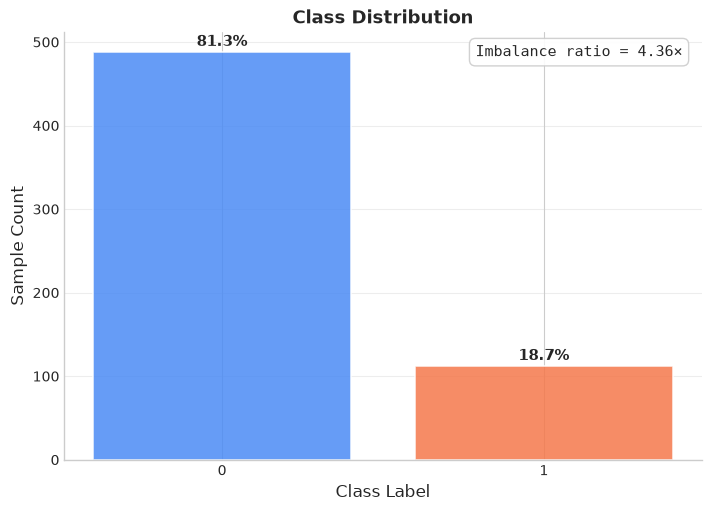

In [8]:
%matplotlib inline
# Generate fairness visualization
fig = report.plot_bias()  # displays the figure

## 7. Latent Space & Representation Analysis
TrustLens can visualize how well your model separates different classes in its latent embedding space. This is critical for understanding if the model has learned robust features or if classes are overlapping dangerously.

Supported methods include:
- **UMAP**: Best for preserving local and global structure (requires `umap-learn`).
- **t-SNE**: Traditional manifold visualization.
- **PCA**: Linear projection (always available).

If the required library (like `umap-learn`) is not installed, TrustLens **gracefully falls back** to the next best available method.

Running representation analysis...


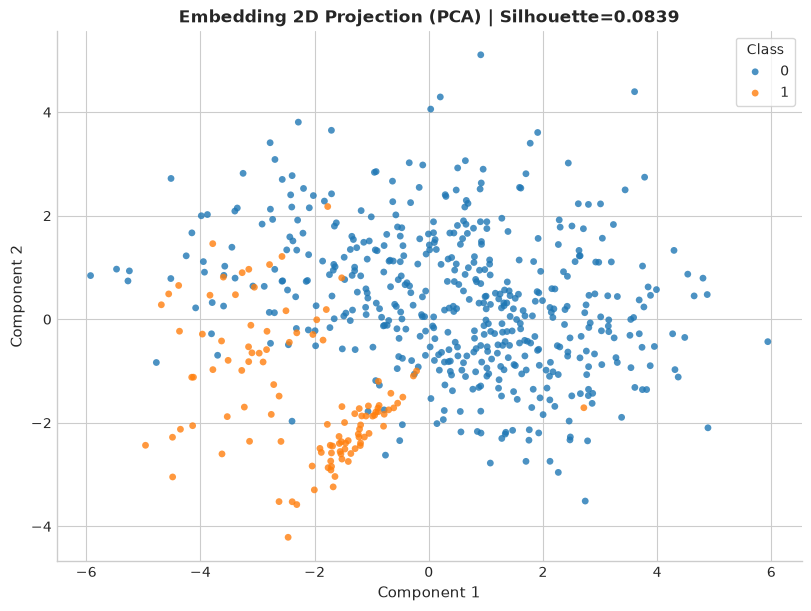

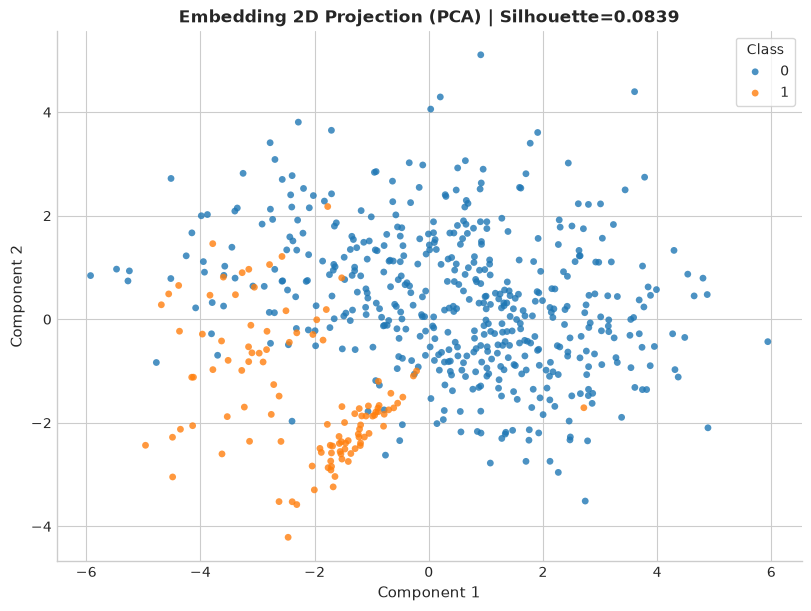

In [9]:
# To visualize embeddings, we pass them to the analyze function.
# For this demo, we'll treat the raw features as 'embeddings'.
embeddings = X_val 

# Run a focused representation analysis
report_rep = analyze(
    model=model,
    X=X_val,
    y_true=y_val,
    embeddings=embeddings,
    modules=["representation"]
)

# Visualize the 2D projection
# If UMAP is installed, it will be used by default. 
# Here we explicitly use PCA for deterministic results in the demo.
report_rep.plot_embedding_2d(method="pca", show=True)

## 8. Sub-Score Details
You can also inspect the individual Trust Score result object for a compact styled breakdown.

In [10]:
report.trust_score

TrustScoreResult(score=46, grade='C')

## 9. Persisting Reports
Save the entire report (JSON results, metadata, and all plots) to a directory for later review or CI/CD integration.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


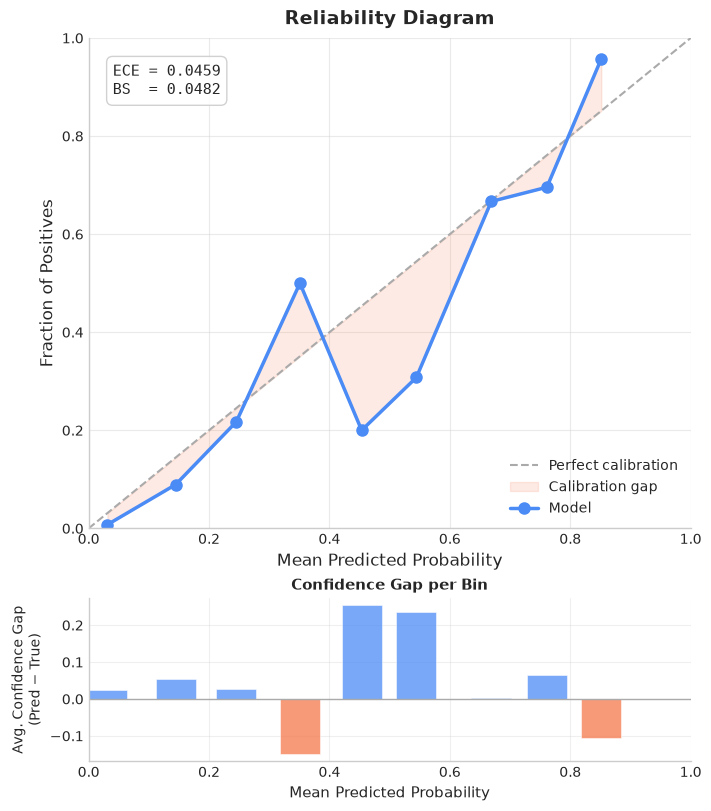

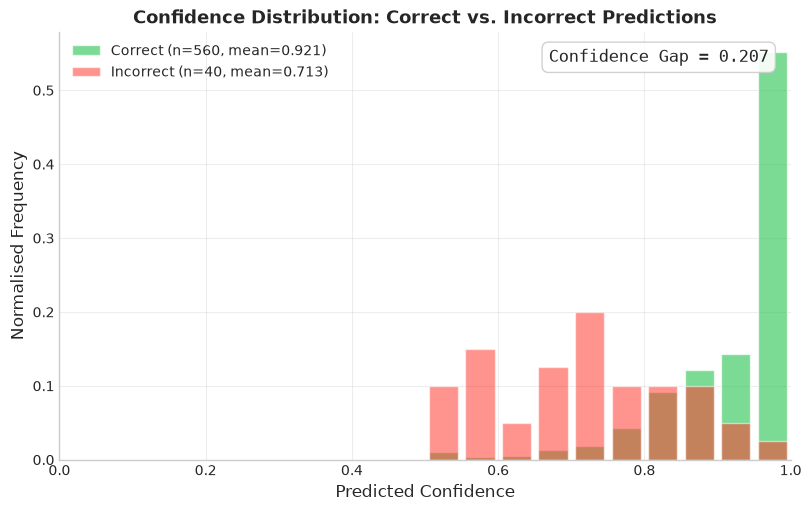

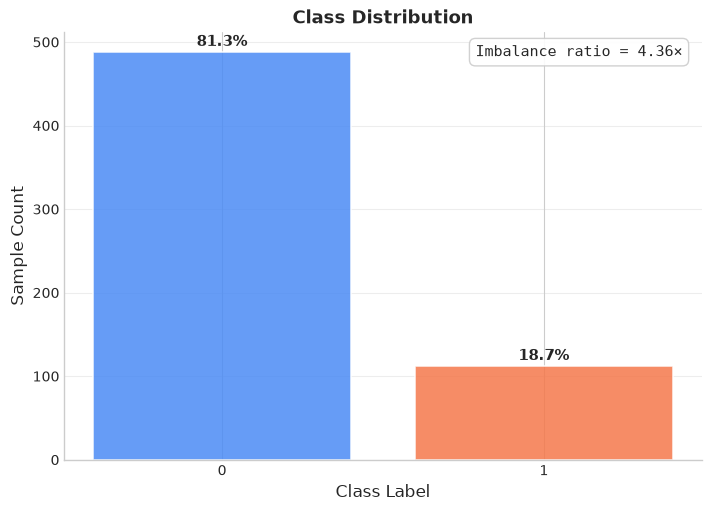

PosixPath('/tmp/tmpu3ogwxvy/trustlens_audit_report')

In [11]:
report.save("trustlens_audit_report")